In [27]:
# Data is from https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

# Define our optimized data structure dictionary
optimized_dtypes = {
    # 1. Categoricals (Low unique count -> high performance gain)
    'discoverymethod': 'category',      # Only ~11 types (Transit, RV, etc.)
    'soltype': 'category',              # Star type (~9 categories like "Sun-like")
    'pl_letter': 'category',            # Planet suffixes ('b', 'c') - only 8 unique!
    'disc_locale': 'category',          # ~4 locales (e.g., IAU)
    
    # 2. Strings (High uniqueness, keep as text to preserve IDs exactly)
    'hd_name': str,                     # e.g., "HD 107383"
    'hip_name': str,                    # e.g., "HIP 60202"
    
    # We can also add other ID columns to stay strictly text:
    'tic_id': str,                      
    'gaia_dr2_id': str,                 
}

# Reading the file with optimizations applied
df = pd.read_csv(
    r"D:\Cline Projects\ExoPlanetData.csv", 
    comment='#',                      # Skip metadata lines starting with '#'
    low_memory=False,                 # Prevents mixed-type warnings
    dtype=optimized_dtypes,           # Applying optimized types
    parse_dates=['disc_pubdate']      # Automatically converts date strings to datetime objects!
)

# Check the results:
print("Data Types Summary: ")
print(df.dtypes.value_counts())       # 'category' appears now!

print("\nSample of Discovery Methods in the data: ")
print(df['discoverymethod'].value_counts().head(10))

Data Types Summary: 
float64     254
object       24
int64         7
category      1
category      1
category      1
category      1
Name: count, dtype: int64

Sample of Discovery Methods in the data: 
discoverymethod
Transit                          35918
Radial Velocity                   2950
Microlensing                       810
Imaging                            192
Transit Timing Variations          167
Eclipse Timing Variations           26
Orbital Brightness Modulation       21
Pulsar Timing                       13
Astrometry                           6
Pulsation Timing Variations          2
Name: count, dtype: int64


C:\Users\Juan\AppData\Local\Temp\ipykernel_10076\867588548.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discovery_by_year = df.groupby(['disc_year', 'discoverymethod']).size().reset_index(name='count')


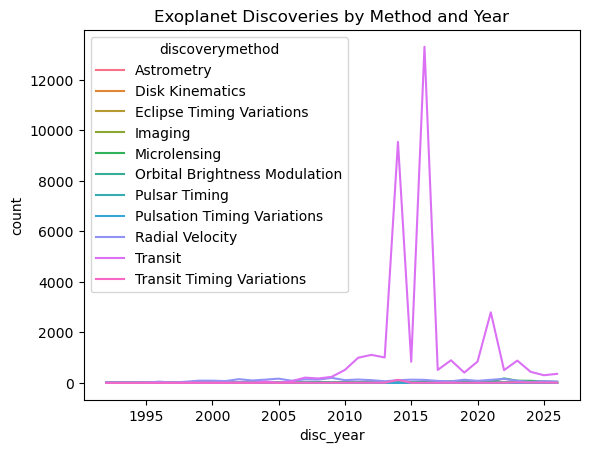

In [28]:
discovery_by_year = df.groupby(['disc_year', 'discoverymethod']).size().reset_index(name='count')

sns.lineplot(data=discovery_by_year, x='disc_year', y='count', hue='discoverymethod')
plt.title('Exoplanet Discoveries by Method and Year')
plt.savefig('Outputs/exoplanet-discoveries-by-method-and-year.svg', format='svg', bbox_inches='tight')
plt.show()

**Note:** The data is biased towards transit method of discovery. <br> Kepler Mission and Transiting Exoplanet Survey Satellite (TESS) mission relied on the transit method for detecting exoplanets. The method measures dips in the host star brightnes that occurs when a planet transits in front of the star. <br> The peaks are from bulk statistical validation where NASA confirmed thousands of planets in batches.

# What star spectral class has the most amount of exoplanets?

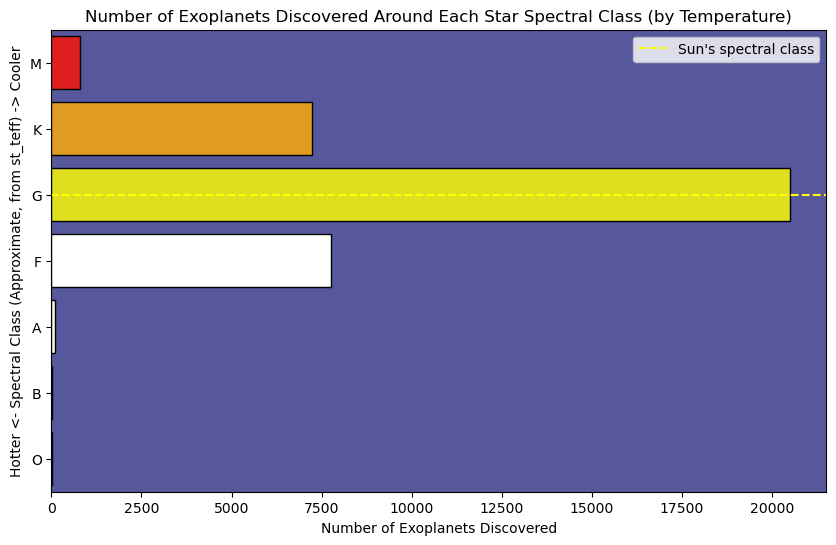

In [29]:
clean_teff = df.dropna(subset=['st_teff']).copy()

# Temperature ranges based on the Harvard Spectral Classification https://lweb.cfa.harvard.edu/~pberlind/atlas/htmls/note.html
bins = [0, 3500, 5000, 6000, 7500, 10000, 25000, float('inf')]
spectral_type = ['M', 'K', 'G', 'F', 'A', 'B', 'O']
clean_teff['spectral_class_approx'] = pd.cut(clean_teff['st_teff'], bins=bins, labels=spectral_type)

#Setting a palette
palette = {
    'M':'red',
    'K':'orange',
    'G':'yellow',
    'F':'white',
    'A':'lightyellow',
    'B':'lightskyblue',
    'O':'aqua'
}

counts = clean_teff['spectral_class_approx'].value_counts().reindex(spectral_type)  # keep O->M or M->O order, not by count

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette=palette, legend=False, edgecolor='black')
plt.title('Number of Exoplanets Discovered Around Each Star Spectral Class (by Temperature)')
plt.xlabel('Number of Exoplanets Discovered')
plt.ylabel('Hotter <- Spectral Class (Approximate, from st_teff) -> Cooler')

# Sun is G-type (~5,778 K)
sun_position = list(counts.index).index('G')
ax.set_facecolor('#57579c')
ax.axhline(y=sun_position, color='yellow', linestyle='--', linewidth=1.5, label="Sun's spectral class")
ax.legend()
plt.savefig('Outputs/num-of-exoplanets-around-each-star-spectral-class.svg', format='svg', bbox_inches='tight')
plt.show()

G-class stars have the most amount of exoplanets. This is a detection bias, not evidence that exoplanets are more common around G-type stars.

In [30]:
print('NaNs: ')
print(clean_teff[['st_lum', 'st_rad', 'st_teff']].isna().sum())
print(clean_teff.shape)

# 'st_lum' has too many NaNs which would make the HR diagram lose 73% of its data
# Luckily, we can derive the luminosity from st_rad and st_teff using Stefan-Boltzmann law. Note: Claude informed me you can derive it 
# This way, we only lose 2.4%

# Surface temp in Kelvin derived from the International Astronomical Union 2015 resolution B3: Table 1 https://iopscience.iop.org/article/10.3847/0004-6256/152/2/41
t_sun = 5772
clean_teff['st_lum_derived'] = np.log10( #log because 'st_lum' is in log 
    (clean_teff['st_rad'] ** 2) * ((clean_teff['st_teff'] / t_sun) ** 4)) #'st_rad' in Solar Radius

# Checking values
checking = clean_teff.dropna(subset=['st_lum', 'st_lum_derived'])
print(checking[['st_lum', 'st_lum_derived']].corr())

# Correlation of .998! Lets fill in the missing values
clean_teff['st_lum_final'] = clean_teff['st_lum'].fillna(clean_teff['st_lum_derived'])

NaNs: 
st_lum     26648
st_rad       878
st_teff        0
dtype: int64
(36441, 290)
                  st_lum  st_lum_derived
st_lum          1.000000        0.998548
st_lum_derived  0.998548        1.000000


# HR Diagrams of Exoplanet Host Stars <br> 
### HR Diagram with all stars

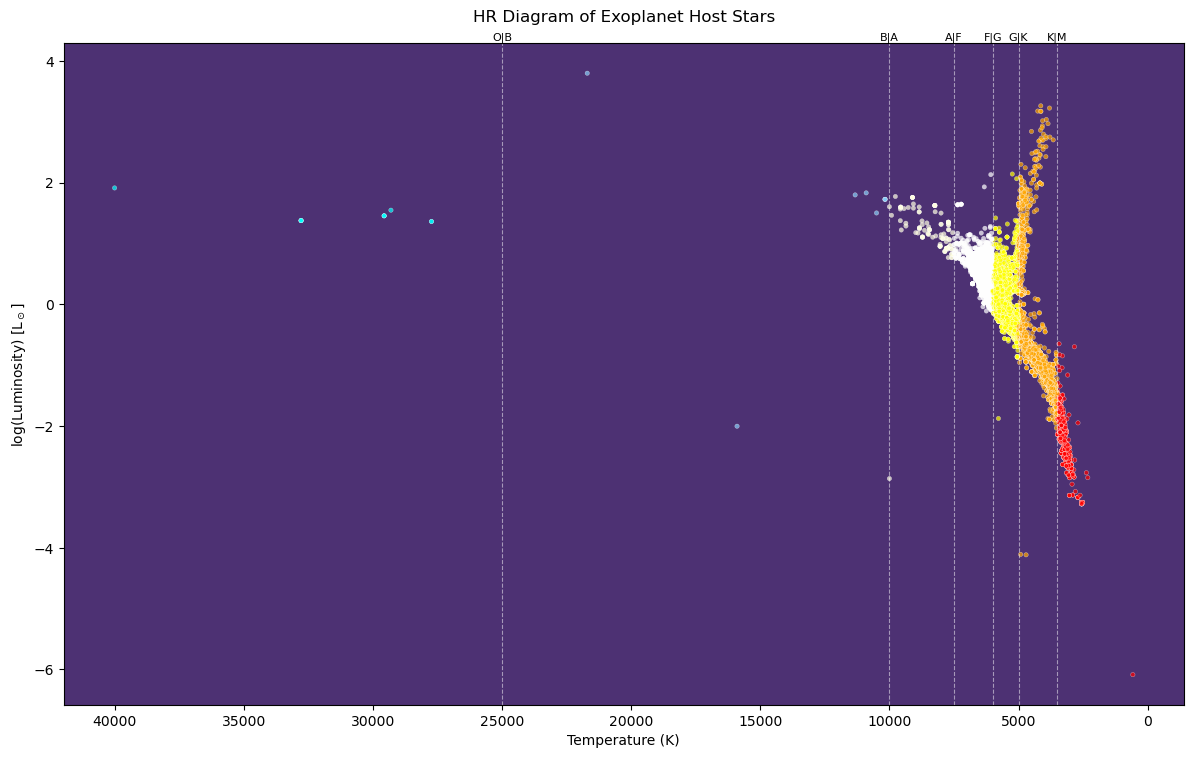

In [31]:
# 5 O-type stars removed. Makes the HR diagram more readable
# clean_teff_filtered = clean_teff[clean_teff['st_teff'] < 25000]

#Boundaries for star temp class
boundaries = {
    'K|M': 3500,
    'G|K': 5000,
    'F|G': 6000,
    'A|F': 7500,
    'B|A': 10000,
    'O|B': 25000 #commenting out to remove outlier axvline
}

plt.figure(figsize=(12, 8))
ax = sns.scatterplot(data=clean_teff, x='st_teff', y='st_lum_final', hue='spectral_class_approx', palette=palette, alpha=0.7, s=10, legend=False)
ax.set_facecolor('#4d3173')
plt.tight_layout()
ax.invert_xaxis() #Temp axis inverted per standard astronomical convention. Hotter Stars on the left. Colder on the right
for label, temp in boundaries.items():
    ax.axvline(x=temp, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(temp, ax.get_ylim()[1] * 1.01, label, color='black', fontsize=8, ha='center')
#ax.set_yscale('log') column 'st_lum''s data is log
plt.subplots_adjust(top=0.9)
plt.xlabel('Temperature (K)')
plt.ylabel('log(Luminosity) [L$_\\odot$]')
plt.title('HR Diagram of Exoplanet Host Stars', y=1.02)
plt.savefig('Outputs/HR-diagram-exoplanet-host-stars.svg', format='svg', bbox_inches='tight')
plt.show()

### HR Diagram focusing on cluster

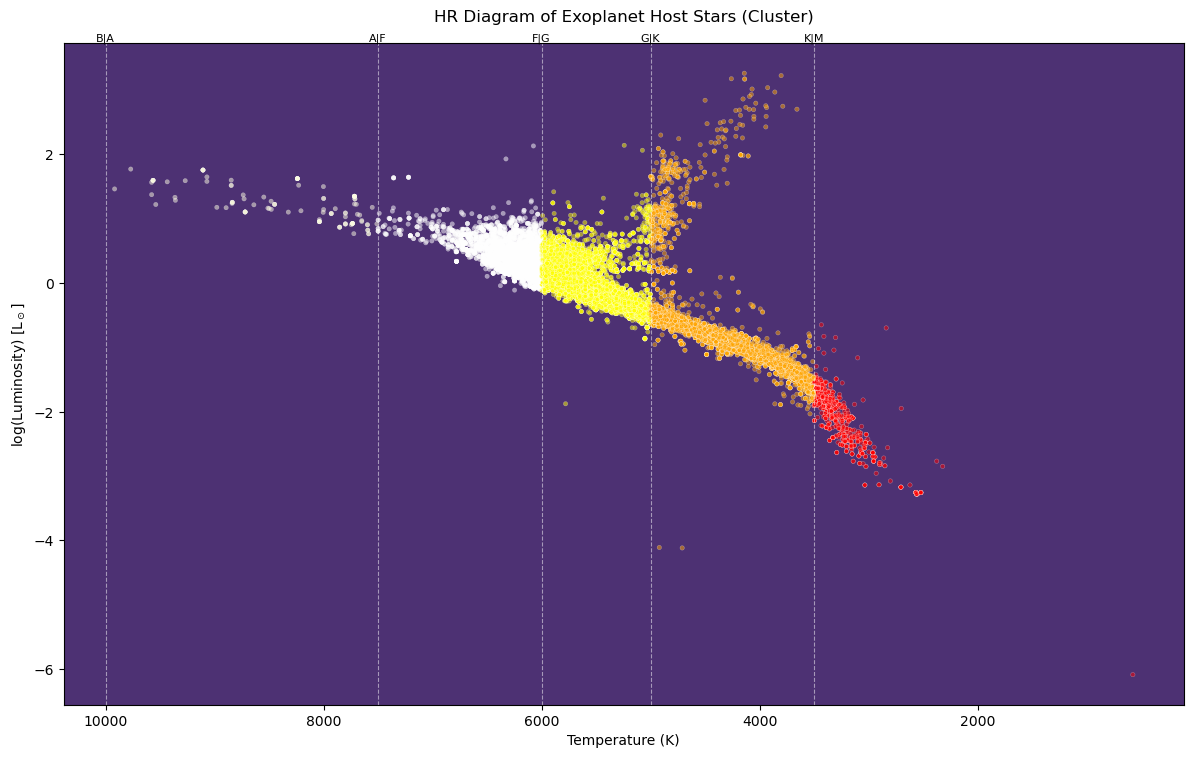

In [32]:
#Removed O and B types to focus on the cluster
clean_teff_filtered = clean_teff[clean_teff['st_teff'] < 10000]

#Boundaries for star temp class
boundaries = {
    'K|M': 3500,
    'G|K': 5000,
    'F|G': 6000,
    'A|F': 7500,
    'B|A': 10000,
    #'O|B': 25000 commenting out to remove outlier axvline
}

plt.figure(figsize=(12, 8))
ax = sns.scatterplot(data=clean_teff_filtered, x='st_teff', y='st_lum_final', hue='spectral_class_approx', palette=palette, alpha=0.5, s=10, legend=False)
ax.set_facecolor('#4d3173')
plt.tight_layout()
ax.invert_xaxis() #Temp axis inverted per standard astronomical convention. Hotter Stars on the left. Colder on the right
for label, temp in boundaries.items():
    ax.axvline(x=temp, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(temp, ax.get_ylim()[1] * 1.01, label, color='black', fontsize=8, ha='center')
#ax.set_yscale('log') column 'st_lum''s data is log
plt.subplots_adjust(top=0.9)
plt.xlabel('Temperature (K)')
plt.ylabel('log(Luminosity) [L$_\\odot$]')
plt.title('HR Diagram of Exoplanet Host Stars (Cluster)', y=1.02)
plt.savefig('Outputs/HR-diagram-exoplanets-host-stars-cluster.svg', format='svg', bbox_inches='tight')
plt.show()

### HR Diagram focusing on most common star-types

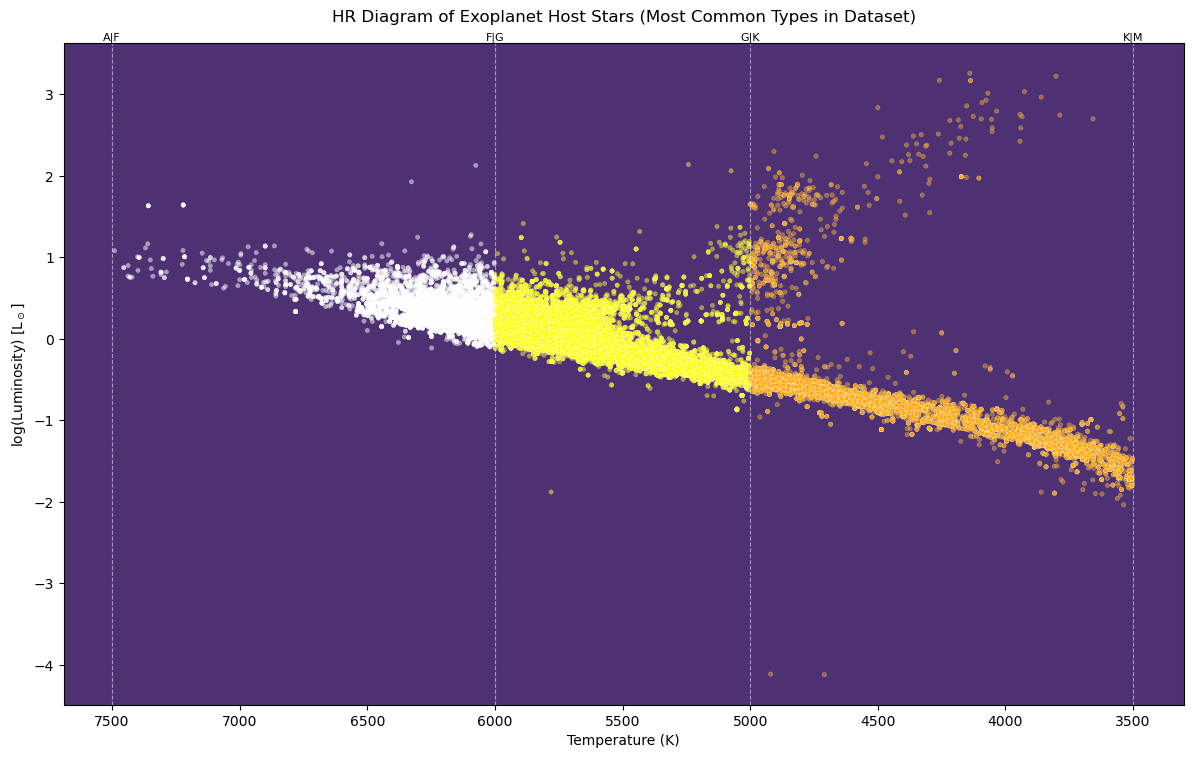

In [33]:
#Focusing on the most common types of star: K, G, and F
clean_teff_filtered2 = clean_teff[(clean_teff['st_teff'] < 7500) & (clean_teff['st_teff'] > 3500)]

#Boundaries for star temp class
boundaries = {
    'K|M': 3500,
    'G|K': 5000,
    'F|G': 6000,
    'A|F': 7500,
    #'B|A': 10000,commenting out to remove outlier axvline
    #'O|B': 25000 commenting out to remove outlier axvline
}

plt.figure(figsize=(12, 8))
ax = sns.scatterplot(data=clean_teff_filtered2, x='st_teff', y='st_lum_final', hue='spectral_class_approx', palette=palette, alpha=0.5, s=10, legend=False)
ax.set_facecolor('#4d3173')
plt.tight_layout()
ax.invert_xaxis() #Temp axis inverted per standard astronomical convention. Hotter Stars on the left. Colder on the right
for label, temp in boundaries.items():
    ax.axvline(x=temp, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(temp, ax.get_ylim()[1] * 1.01, label, color='black', fontsize=8, ha='center')
#ax.set_yscale('log') column 'st_lum''s data is log
plt.subplots_adjust(top=0.9)
plt.xlabel('Temperature (K)')
plt.ylabel('log(Luminosity) [L$_\\odot$]')
plt.title('HR Diagram of Exoplanet Host Stars (Most Common Types in Dataset)', y=1.02)
plt.savefig('Outputs/HR-diagram-exoplanets-host-stars-most-common.svg', format='svg', bbox_inches='tight')
plt.show()

# Plotting stars in 3D space

Converting `ra`/`dec`/`sy_dist` to Cartesian (x,y,z)

In [34]:

coords = clean_teff.dropna(subset=['ra', 'dec', 'sy_dist']).copy()

ra_rad = np.radians(coords['ra'])
dec_rad = np.radians(coords['dec'])
dist = coords['sy_dist']  # parsecs

coords['x'] = dist * np.cos(dec_rad) * np.cos(ra_rad)
coords['y'] = dist * np.cos(dec_rad) * np.sin(ra_rad)
coords['z'] = dist * np.sin(dec_rad)

In [35]:

fig = px.scatter_3d(
    coords, x= 'x', y= 'y', z= 'z',
    color = 'spectral_class_approx',  # Reusing existing column
    color_discrete_map = palette,     # Using existing color dict
    hover_name = 'hostname',          # Shows star name on hover, if column exists
    opacity = 0.7,
    title = 'Exoplanet Host Stars in 3D Space (Earth at Origin)'
)

fig.update_layout(
    legend = dict(
        font = dict(size=16, color='white'),
        itemsizing ='constant',  # Makes legend markers a consistent, larger size regardless of actual point size on the plot
    ),
    scene=dict(
        xaxis=dict(backgroundcolor='black', gridcolor='gray', color='white'),
        yaxis=dict(backgroundcolor='black', gridcolor='gray', color='white'),
        zaxis=dict(backgroundcolor='black', gridcolor='gray', color='white'),
    ),
    paper_bgcolor='black',
    font_color='white',
    title_font_color='white'
)

fig.update_traces(marker=dict(size=2, opacity=0.4))
fig.write_html('Outputs/exoplanet_3d.html')
fig.show()

# Missing Data

sy_kepmagerr1       100.000000
sy_kepmagerr2       100.000000
sy_icmagerr1         99.900264
sy_icmagerr2         99.900264
sy_icmag             99.887797
pl_occdeperr1        99.882811
pl_occdeperr2        99.882811
pl_occdep            99.875330
pl_occdeplim         99.875330
pl_trueobliqerr1     99.827956
pl_trueobliqerr2     99.827956
pl_trueobliq         99.812996
pl_trueobliqlim      99.812996
pl_cmasseerr1        99.790555
pl_cmasseerr2        99.790555
pl_cmassjerr2        99.790555
pl_cmassjerr1        99.790555
pl_cmassjlim         99.780581
pl_cmassj            99.780581
pl_cmasselim         99.780581
pl_cmasse            99.780581
pl_projobliqerr1     99.311824
pl_projobliqerr2     99.311824
pl_projobliqlim      99.309330
pl_projobliq         99.309330
st_rotperr2          97.571436
st_rotperr1          97.571436
st_rotp              97.082731
st_rotplim           97.082731
st_radverr2          95.831048
dtype: float64


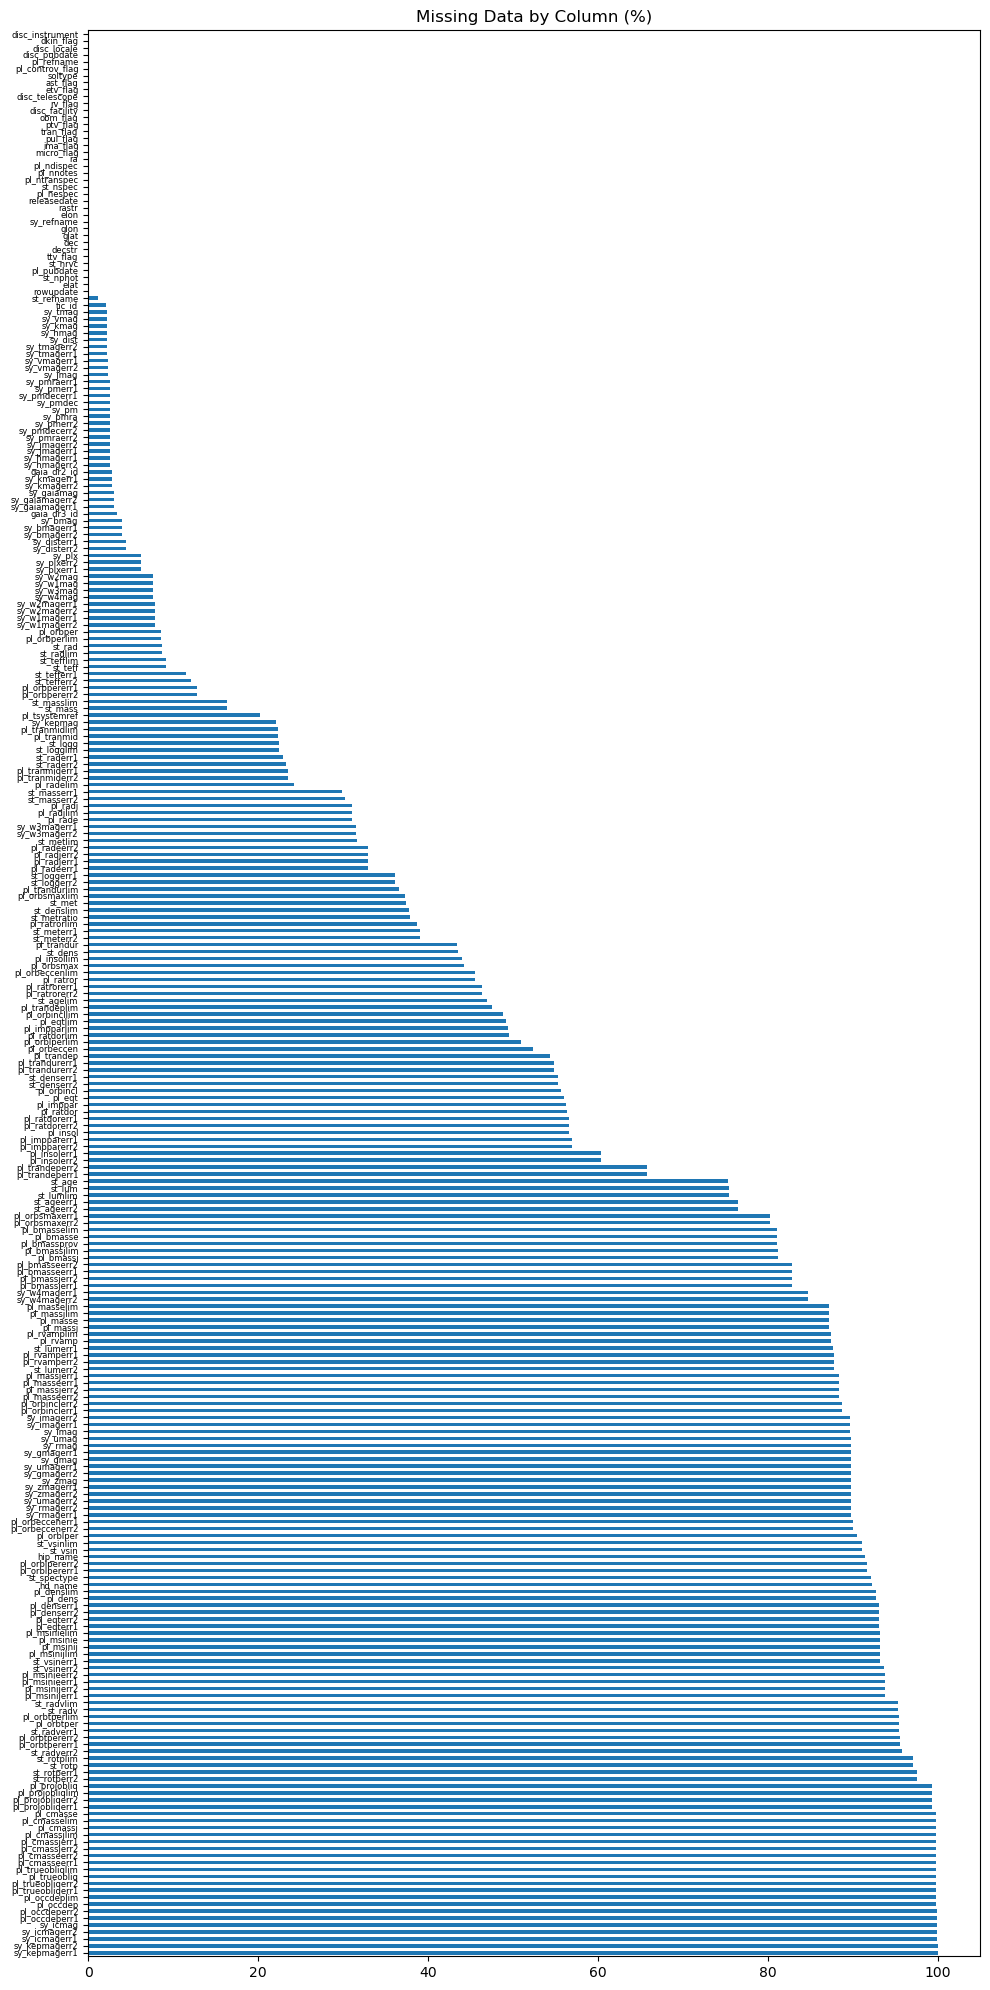

In [36]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct.head(30))  # top 30 most-missing columns
#print(missing_pct.head(50))  # top 50 most-missing columns
#print(missing_pct.head(100))  # top 100 most-missing columns
#print(missing_pct.head(140))  # top 140 most-missing columns

plt.figure(figsize=(10, 20))
missing_pct[missing_pct > 0].plot(kind='barh')
plt.title('Missing Data by Column (%)')
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig('Outputs/missing-data-full.svg', format='svg', bbox_inches='tight')
#plt.show() # Commented out because it is a LONG figure

In [37]:
bins = [0, 10, 25, 50, 75, 90, 100]
labels = ['0-10%', '10-25%', '25-50%', '50-75%', '75-90%', '90-100%']
summary = pd.cut(missing_pct, bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()
print(summary)

0-10%      104
10-25%      17
25-50%      36
50-75%      20
75-90%      49
90-100%     63
Name: count, dtype: int64


In [38]:
top_100_missing = missing_pct.head(100)
prefix_counts = top_100_missing.index.map(lambda c: c.split('_')[0]).value_counts()
print(prefix_counts)

pl     61
sy     22
st     15
hd      1
hip     1
Name: count, dtype: int64


# Exoplanet Orbital Periods

count    3.667900e+04
mean     1.193692e+04
std      2.100243e+06
min      9.070629e-02
25%      4.370345e+00
50%      1.030448e+01
75%      2.665656e+01
max      4.020000e+08
Name: pl_orbper, dtype: float64


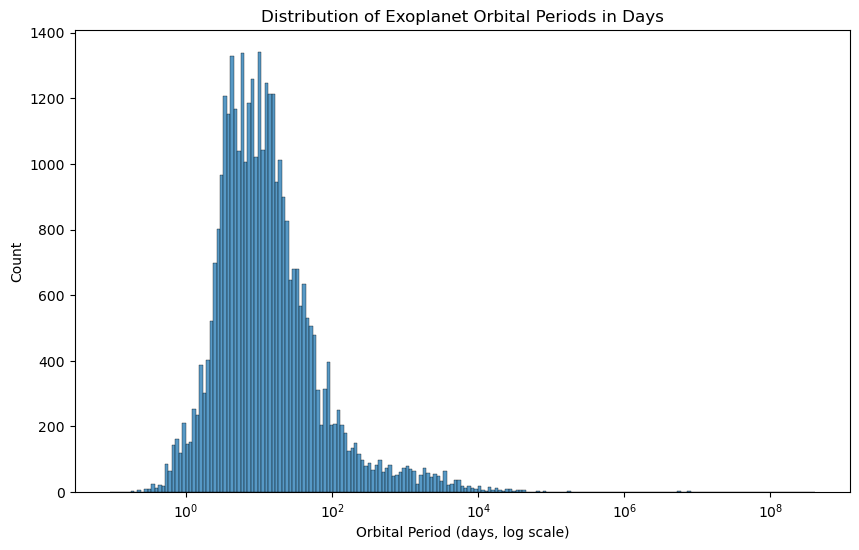

In [39]:
orbper_clean = df.dropna(subset=['pl_orbper']).copy()
print(orbper_clean['pl_orbper'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(orbper_clean['pl_orbper'], log_scale=True)
plt.xlabel('Orbital Period (days, log scale)')
plt.ylabel('Count')
plt.title('Distribution of Exoplanet Orbital Periods in Days')
plt.savefig('Outputs/hist-exoplanet-orbital-period-in-days.svg', format='svg', bbox_inches='tight')
plt.show()

A right-skewed histogram. This means there are a few outliers driving up the orbital period preventing us from seeing the true distribution. 

In [40]:
threshold = orbper_clean['pl_orbper'].quantile(0.99)  # top 1% cutoff
top_1pct = orbper_clean[orbper_clean['pl_orbper'] >= threshold]

print(f"Top 1% = periods >= {threshold:.1f} days, n={len(top_1pct)}")
print(top_1pct['discoverymethod'].value_counts(normalize=True).mul(100).round(1))

Top 1% = periods >= 3397.7 days, n=367
discoverymethod
Radial Velocity                  80.9
Imaging                          13.6
Eclipse Timing Variations         2.7
Microlensing                      1.6
Astrometry                        0.3
Transit Timing Variations         0.3
Pulsar Timing                     0.3
Transit                           0.3
Disk Kinematics                   0.0
Orbital Brightness Modulation     0.0
Pulsation Timing Variations       0.0
Name: proportion, dtype: float64


Looking at the cell above, we can conclude that radial velocity and imaging discovery methods are better suited for discovering exoplanets with long orbital periods. This explains the right-skewed histogram. As shown earlier, 89.55% of discoveries use transit as the most common method of exoplanet discoveries, so we will focus on that method. 

### Orbital periods using only transit discovery method

count    33497.000000
mean        23.892371
std         56.080546
min          0.112007
25%          4.178266
50%          9.458890
75%         21.526257
max       3650.000000
Name: pl_orbper, dtype: float64


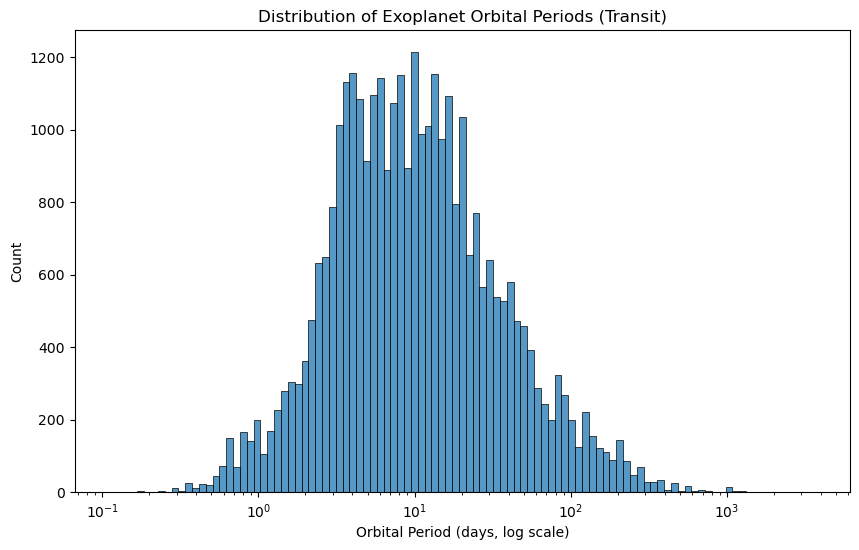

In [41]:
transit_only = orbper_clean[orbper_clean['discoverymethod'] == 'Transit']
print(transit_only['pl_orbper'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(transit_only['pl_orbper'], log_scale=True)
plt.xlabel('Orbital Period (days, log scale)')
plt.ylabel('Count')
plt.title('Distribution of Exoplanet Orbital Periods (Transit)')
plt.savefig('Outputs/dist-exoplanet-orbper-transit.svg', format='svg', bbox_inches='tight')
plt.show()

The mean (23.89 days) is notably higher than the median (9.45 days) showing the distribution is still right-skewed even after filtering for transit-only discovery methods. A small number of long-period exoplanets are still driving up the average. Looking at the histogram and the IQR shows transit-detected exoplanets have orbital periods ranging from a few days to a few weeks, meaning most of these exoplanets orbit very close to their host star. <br> 
Transit method is mechanically biased toward detecting shorter-period exoplanets, since confirming a transit typically requires observing multiple repeated events within a survey's monitoring window. A planet with a multi-year orbit transits far less often, making it harder, though not impossible, to catch enough repeats for confirmation. This matches what's seen in the data: the median transit-detected period is just 9.45 days, though periods extending beyond 365 days are still present, likely from longer surveys like Kepler's continuous 4-year observation window.

Below is an example of a short-period transisting exoplanet

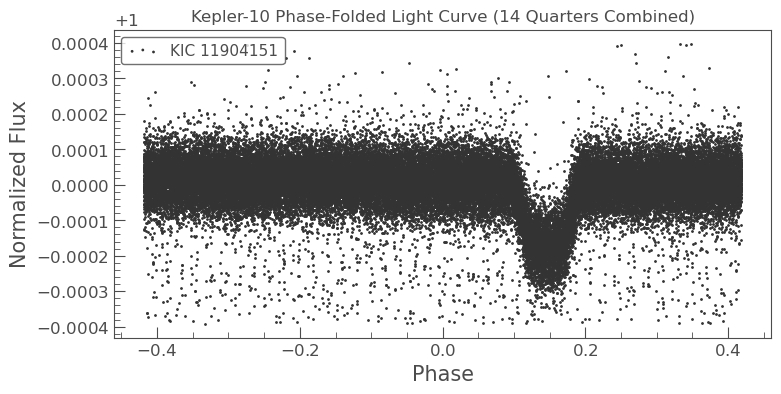

In [42]:
# lightkurve is open-source package for Kepler and TESS time series analysis
import lightkurve as lk

search_result = lk.search_lightcurve('Kepler-10', mission='Kepler', cadence='long')
kepler_results = search_result[search_result.author == 'Kepler']
lc_collection = kepler_results.download_all()
lc = lc_collection.stitch().flatten().remove_outliers()
lc = lc.remove_nans()

period = 0.837495 #Kepler-10b's known orbital period, in days
folded = lc.fold(period=period)
folded.scatter()
plt.title('Kepler-10 Phase-Folded Light Curve (14 Quarters Combined)')
plt.xlabel('Phase')
plt.ylabel('Normalized Flux')
plt.savefig('Outputs/kepler-10b-phasefolded-light-curve.svg', format='svg', bbox_inches='tight')
plt.show()

The dip seen between phase 0.0 and 0.2 shows an object transiting infront of the star, like a planet! <br> **Note:** KIC 11904151 is the catalog identifier for the star Kepler-10

# `st_mass`

In [43]:
df['st_mass'].isna().sum() / len(df) * 100

np.float64(16.311773799431506)

With 16.31% missing, could we fill in the missing values by deriving stellar mass from mass-luminosity relationship?

                  st_mass  st_mass_derived
st_mass          1.000000         0.764649
st_mass_derived  0.764649         1.000000


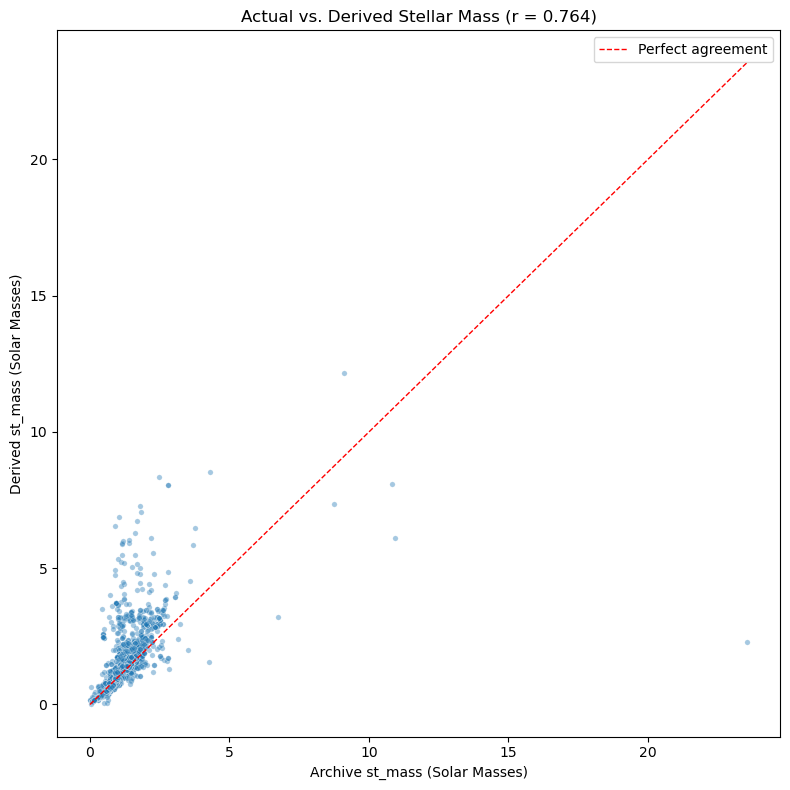

In [44]:
M_sun = 1  # in solar masses, since your data's presumably already in solar units

st_mass_check = clean_teff.dropna(subset=['st_mass', 'st_lum_final']).copy()
st_mass_check['st_mass_derived'] = st_mass_check['st_lum_final'].apply(lambda l: 10**l) ** (1/3.5)

print(st_mass_check[['st_mass', 'st_mass_derived']].corr())

plt.figure(figsize=(8, 8))
sns.scatterplot(x=st_mass_check['st_mass'], y=st_mass_check['st_mass_derived'], alpha=0.4, s=15)

# Reference line: perfect agreement would fall exactly on this diagonal
lims = [0, max(st_mass_check['st_mass'].max(), st_mass_check['st_mass_derived'].max())]
plt.plot(lims, lims, color='red', linestyle='--', linewidth=1, label='Perfect agreement')

plt.xlabel('Archive st_mass (Solar Masses)')
plt.ylabel('Derived st_mass (Solar Masses)')
plt.title('Actual vs. Derived Stellar Mass (r = 0.764)')
plt.legend()
plt.tight_layout()
plt.savefig('Outputs/st-mass-derived-scatter.svg', format='svg', bbox_inches='tight')
plt.show()

Attempted to derive missing `st_mass` values using the mass-luminosity relation (M/M☉ ≈ (L/L☉)^(1/3.5)), following the same approach that worked well for luminosity. Unlike the Stefan-Boltzmann derivation (correlation of 0.998), this produced a much weaker correlation of 0.764 against the archive's own st_mass values, reflecting that, unlike Stefan-Boltzmann's exact physical law, the mass-luminosity relation is only a rough approximation with an exponent that varies by stellar mass range and breaks down for non-main-sequence stars. Given this uncertainty, `st_mass_derived` was not used to fill missing values. The original 16.31% missing in `st_mass` was left as-is rather than risk introducing unreliable estimates.